In [3]:
# 7.1

import numpy as np
from numpy import linalg as la 

np.set_printoptions(suppress=True)

A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
print(A)

det = la.det(A)
print(det)

B = np.array([2,2,-1])
sol = la.solve(A,B) 
print(sol)

orthogonality = np.allclose(A.T @ A, np.eye(3))
print(orthogonality) 

eigenvals = la.eigvals(A)
print(eigenvals)

[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
1.0
[10. -1. -2.]
False
[ 1.         -4.79128785 -0.20871215]


In [8]:
import numpy as np
from numpy import linalg as la

def Rz(deg):
    angle = np.radians(deg)
    c, s = np.cos(angle), np.sin(angle)
    return np.array([c, s, 0, -s, c, 0, 0 ,0, 1]).reshape(3, 3)


def Ry(deg):
    angle = np.radians(deg)
    c, s = np.cos(angle), np.sin(angle)
    return np.array([c, 0, -s, 0, 1, 0, s, 0, c]).reshape(3, 3)

theta1 = 192.25
theta2 = 90-27.4
theta3 = 180-123

E = Rz(theta3) @ Ry(theta2) @ Rz(theta1)

print(E)

orthogonal = np.allclose(E @ E.T, np.eye(3))
detE = la.det(E)

print(orthogonal)
print(detE)

eigenvals = la.eigvals(E)
print(eigenvals)

alpha = 192.25
delta = 27.4
a_rad = np.radians(alpha)
d_rad = np.radians(delta)

v = np.array([np.cos(d_rad)*np.cos(a_rad), np.cos(d_rad)*np.sin(a_rad), np.sin(d_rad)])

print(v) 

v2 = E @ v
print(v2)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
True
1.0
[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
[-0.86760081 -0.1883746   0.46019978]
[0. 0. 1.]


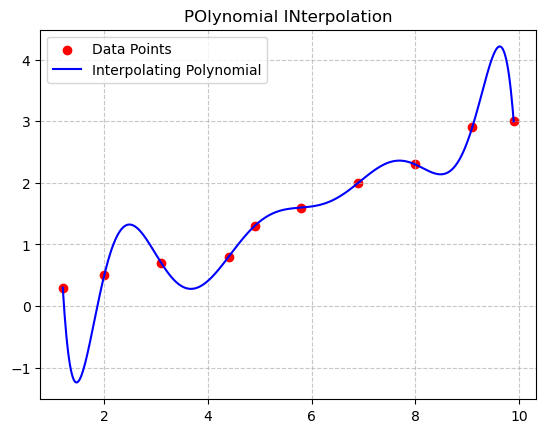

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as la

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

def solvi(x, y):  
    n = len(x)
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            A[i, j] = x[i]**j
    coeffs = la.solve(A, y) 
    return coeffs 

coeffs = solvi(x, y)

def evaluation(coeffs, x_val):
    res = 0
    for i, a in enumerate(coeffs):
        res += a*(x_val**i)
    return res

x_fine = np.linspace(min(x), max(x), 500)
y_poly = evaluation(coeffs, x_fine)

plt.figure()
plt.scatter(x, y, color='red', label = 'Data Points')
plt.plot(x_fine, y_poly, label = 'Interpolating Polynomial', color = 'blue')
plt.title('POlynomial INterpolation')
plt.legend()
plt.grid(True, linestyle='--', alpha = 0.7)
plt.show()


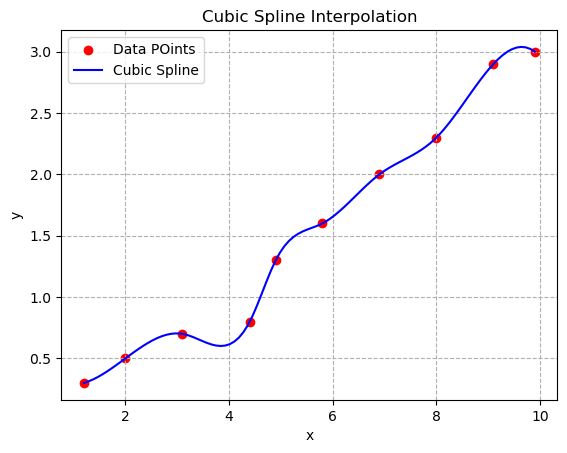

In [22]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.interpolate import interp1d

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])


f = interp1d(x, y, kind='cubic')
xnew = np.linspace(x.min(), x.max(), 100)
ycub = f(xnew)

plt.figure()
plt.scatter(x, y, color='red', label='Data POints')
plt.plot(xnew, ycub, label='Cubic Spline', color='blue')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

class Interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.f_linear = interp1d(x, y, kind='cubic')
        self.f_spline = interp1d(x, y, kind='cubic')
        self.poly_coeffs = np.polyfit(x, y, len(x) -1)
        self.f_poly = np.poly1d(self.poly_coeffs)

    def choose(self, x_hat, method='spline'):
        if method == 'linear':
            return self.f_linear(x_hat)
        elif method == 'spline':
            return self.f_spline(x_hat)
        elif method == 'poly':
            return self.f_poly(x_hat)
        else:
            raise ValueError("bro what u doing")

mod = Interpolation(x, y) 

x_val = 2

y_lin = mod.choose(x_val, method='linear')
y_spl = mod.choose(x_val, method='spline')
y_poly = mod.choose(x_val, method='poly')

In [18]:
import numpy as np

I = np.array([[2.0,4.1], [2.5,3.8]])
x = 0.2
y = 0.7

I0, I1 = I[0,0], I[0, 1]
I2, I3 = I[1, 0], I[1, 1]

lam = x -int(x)
mu = y-int(y)

big_I = (1-lam)*(1-mu)*I0+lam*(1-mu)*I1+mu*(1-lam)*I2+lam*mu*I3

print(big_I)

2.658


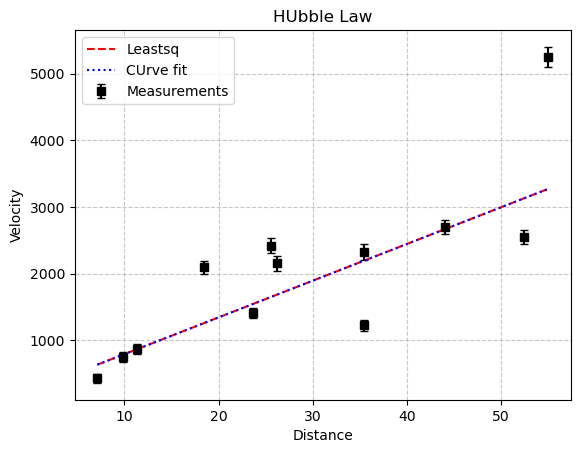

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

data = np.array([
   [18.49,     2094.75,    0.3,           100],
   [35.48,     2320.87,    2.2,           120],
   [35.48,     1224.9,     3.0,           80],
   [11.34,     872.13,     1.2,           80],
   [7.12,      432.2,      0.4,           70],
   [9.82,      751,        0.3,           75],
   [23.66,     1410,       2.3,           70],
   [44,        2700,       4.0,           110],
   [52.4,      2550,       5.2,           100],
   [55,        5253,       6.1,           150],
   [25.6,      2419,       3.2,           110],
   [26.19,     2158,       2.8,           110]
])

d = data[:, 0]
v = data[:, 1]
err_v = data[:, 3]

def model(params, x):
    a, b = params
    return a+b*x

def residuals(params, x, y, err):
    return(y-model(params,x))/err

initial = [0, 70]

params_ls, success = leastsq(residuals, initial, args=(d, v, err_v))
a_ls, b_ls = params_ls

def func(x, a, b):
    return a+b*x

popt, pcov = curve_fit(func, d, v, sigma=err_v, absolute_sigma=True)
a_cf, b_cf = popt

plt.figure()
plt.errorbar(d, v, yerr=err_v, color='black', fmt='s', label='Measurements', capsize=3)
x_range = np.linspace(min(d), max(d), 100)
plt.plot(x_range, model(params_ls, x_range), 'r--', label = 'Leastsq')
plt.plot(x_range, func(x_range, *popt), 'b:', label='CUrve fit')
plt.xlabel('Distance')
plt.ylabel('Velocity')
plt.title('HUbble Law')
plt.legend()
plt.grid(True, linestyle='--', alpha = 0.7)
plt.show()